# Estudio Deep Q-learning

Comparativa SARSA vs DQN y evaluación en LunarLander-v2.

In [1]:
!git clone -b ADRIAN https://github.com/fraycarmona/eml_tabular_grupo_17
%cd eml_tabular_grupo_17/src/EntornosComplejos


Cloning into 'eml_tabular_grupo_17'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 123 (delta 46), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 1.76 MiB | 5.70 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/eml_tabular_grupo_17/src/EntornosComplejos


In [2]:

SEED = 2024
import random
import numpy as np
import pandas as pd
import torch
import gymnasium as gym

from agents.pendulumdqnagent import PendulumDqnAgent
from agents.pendulumsarsaagent import PendulumSarsaAgent
from plotting.plotting import plotlearningcurve, plotlosscurve

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
def random_baseline(env_name, episodes=500, max_steps=500, seed=SEED):
    env_r = gym.make(env_name)
    rewards, lengths = [], []
    for ep in range(episodes):
        state, _ = env_r.reset(seed=seed + ep)
        total = 0.0
        for t in range(1, max_steps + 1):
            action = env_r.action_space.sample()
            state, r, terminated, truncated, _ = env_r.step(action)
            total += r
            if terminated or truncated:
                break
        rewards.append(total)
        lengths.append(t)
    env_r.close()
    return {'rewards': rewards, 'lengths': lengths}


In [4]:
env_p = gym.make('Pendulum-v1')
dqn_agent = PendulumDqnAgent(env=env_p, seed=SEED)
history_dqn = dqn_agent.train(num_episodes=250, max_steps=200)


In [5]:
sarsa_agent = PendulumSarsaAgent(env=gym.make('Pendulum-v1'), seed=SEED)
history_sarsa = sarsa_agent.train(num_episodes=200, max_steps=200)
baseline_p = random_baseline('Pendulum-v1', episodes=150, max_steps=200)


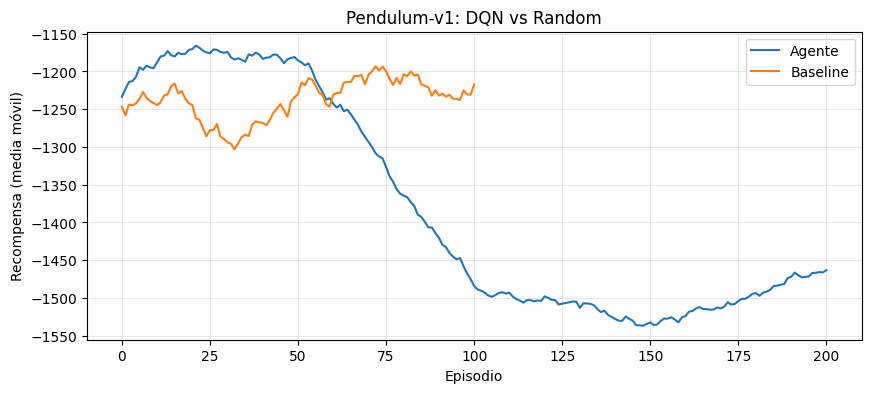

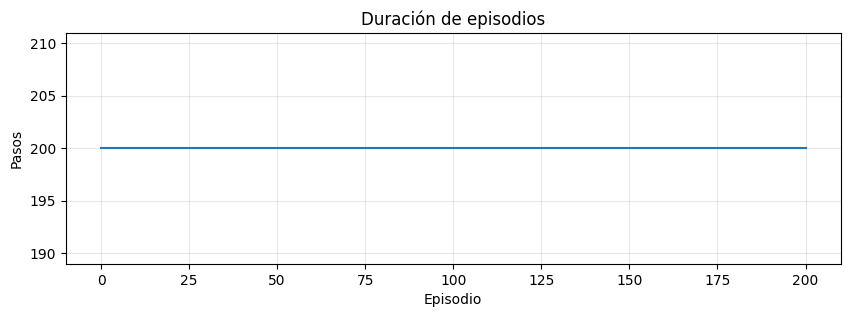

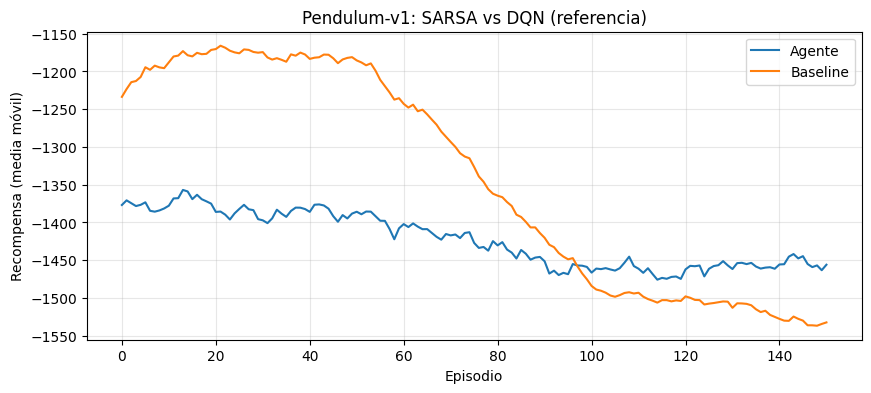

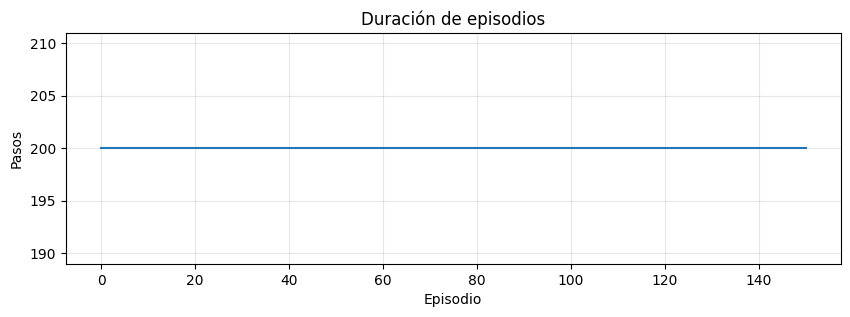

In [6]:
plotlearningcurve(
    rewardshistory=history_dqn['rewards'],
    baselinehistory=baseline_p['rewards'],
    episode_length_history=history_dqn['lengths'],
    window=50,
    title='Pendulum-v1: DQN vs Random'
)

plotlearningcurve(
    rewardshistory=history_sarsa['rewards'],
    baselinehistory=history_dqn['rewards'][:len(history_sarsa['rewards'])],
    episode_length_history=history_sarsa['lengths'],
    window=50,
    title='Pendulum-v1: SARSA vs DQN (referencia)'
)


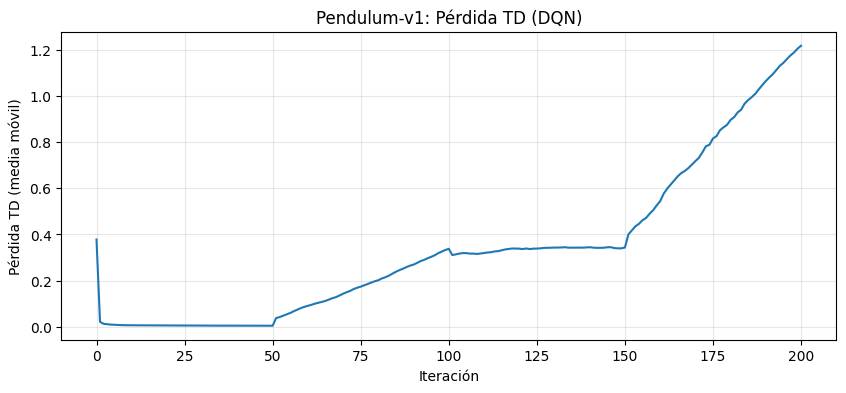

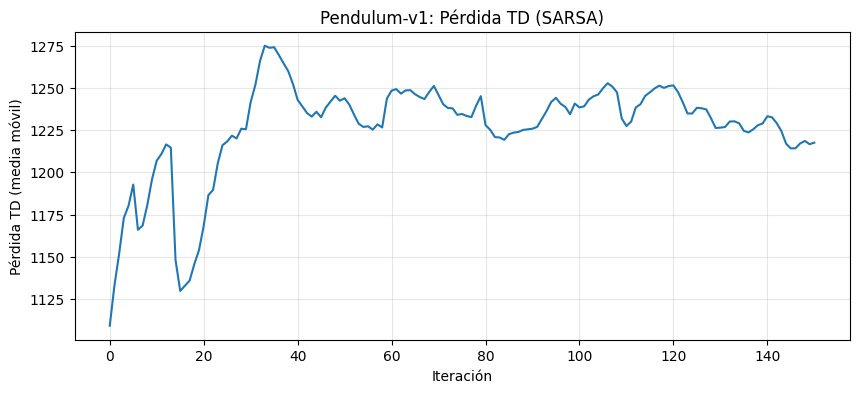

In [7]:
plotlosscurve(history_dqn['losses'], window=50, title='Pendulum-v1: Pérdida TD (DQN)')
plotlosscurve(history_sarsa['losses'], window=50, title='Pendulum-v1: Pérdida TD (SARSA)')


In [8]:
try:
    env_l = gym.make('LunarLander-v2')
    lunar_agent = PendulumDqnAgent(env=env_l, seed=SEED)
    history_lunar = lunar_agent.train(num_episodes=50, max_steps=400)
    baseline_lunar = random_baseline('LunarLander-v2', episodes=50, max_steps=400)

    plotlearningcurve(
        rewardshistory=history_lunar['rewards'],
        baselinehistory=baseline_lunar['rewards'],
        episode_length_history=history_lunar['lengths'],
        window=20,
        title='LunarLander-v2: DQN vs Random'
    )
    plotlosscurve(history_lunar['losses'], window=20, title='LunarLander-v2: Pérdida TD (DQN)')
except Exception as e:
    print('No se pudo ejecutar LunarLander-v2 en este entorno:', e)
    history_lunar = None
    baseline_lunar = None


No se pudo ejecutar LunarLander-v2 en este entorno: Environment version v2 for `LunarLander` is deprecated. Please use `LunarLander-v3` instead.


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


In [9]:
results = []

pend_dqn = np.mean(history_dqn['rewards'][-100:])
pend_sarsa = np.mean(history_sarsa['rewards'][-100:])
pend_random = np.mean(baseline_p['rewards'])

results.append({
    'Entorno': 'Pendulum-v1',
    'Agente': 'DQN',
    'Media recompensa': pend_dqn,
    '% mejora vs random': ((pend_dqn - pend_random) / (abs(pend_random) + 1e-8)) * 100,
})
results.append({
    'Entorno': 'Pendulum-v1',
    'Agente': 'SARSA',
    'Media recompensa': pend_sarsa,
    '% mejora vs random': ((pend_sarsa - pend_random) / (abs(pend_random) + 1e-8)) * 100,
})

if history_lunar is not None:
    lunar_dqn = np.mean(history_lunar['rewards'][-100:])
    lunar_random = np.mean(baseline_lunar['rewards'])
    results.append({
        'Entorno': 'LunarLander-v2',
        'Agente': 'DQN',
        'Media recompensa': lunar_dqn,
        '% mejora vs random': ((lunar_dqn - lunar_random) / (abs(lunar_random) + 1e-8)) * 100,
    })

pd.DataFrame(results)


,Entorno,Agente,Media recompensa,% mejora vs random
0,Pendulum-v1,DQN,-1497.668158,-21.628456
1,Pendulum-v1,SARSA,-1461.116266,-18.660008
